In [1]:
# ==========================================
# CELL 1: Imports & Setup
# ==========================================
import os
import random
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import torchvision.transforms.functional as TF
from PIL import Image
from tqdm.auto import tqdm

# Initialize compute hardware
compute_device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Hardware assigned: {compute_device}")

Hardware assigned: cuda


In [2]:
# ==========================================
# CELL 2: On-the-Fly Geometric Dataset
# ==========================================
class ClockFaceBoundsDataset(Dataset):
    """
    Dynamically augments 'perfectly centered' synthetic data by panning 
    and zooming. This forces the network to learn translation invariance 
    for real-world clock photos.
    """
    def __init__(self, base_path, partition="train"):
        self.base_path = base_path
        self.partition = partition
        
        # Point to the analog partition's specific CSV
        self.csv_file_path = os.path.join(self.base_path, "analog", self.partition, "labels.csv")
        self.metadata = pd.read_csv(self.csv_file_path)
        
        # Standardize for ResNet backbone
        self.req_size = 224

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        record = self.metadata.iloc[index]
        
        # Target the clean background if available, otherwise fallback to the standard analog face
        if "clean_filename" in record and pd.notna(record["clean_filename"]):
            img_file = str(record["clean_filename"])
        else:
            img_file = str(record["filename"])
            
        full_img_path = os.path.join(self.base_path, "analog", self.partition, img_file)
        
        raw_img = Image.open(full_img_path).convert("RGB")
        width, height = raw_img.size

        # Default synthetic coordinates (always centered)
        base_cx = 0.5  
        base_cy = 0.5  
        base_rad_px = (min(width, height) // 2) - max(5, width // 25)
        base_r = base_rad_px / width 

        # 3. Dynamic Transformation Vectors
        zoom_factor = random.uniform(0.7, 1.1)
        pan_x_pct = random.uniform(-0.15, 0.15)
        pan_y_pct = random.uniform(-0.15, 0.15)
        
        move_px = (int(pan_x_pct * width), int(pan_y_pct * height))

        # Perform the affine warp (empty boundaries fill with black)
        altered_img = TF.affine(raw_img, angle=0, translate=move_px, scale=zoom_factor, shear=0, fill=0)
        
        tensor_img = TF.resize(altered_img, (self.req_size, self.req_size))
        tensor_img = TF.to_tensor(tensor_img)

        # 4. Map the geometric adjustments to the ground-truth coordinates
        updated_cx = base_cx + pan_x_pct
        updated_cy = base_cy + pan_y_pct
        updated_r = base_r * zoom_factor

        target_bounds = torch.tensor([updated_cx, updated_cy, updated_r], dtype=torch.float32)

        return tensor_img, target_bounds

In [3]:
# ==========================================
# CELL 3: CNN Regressor Architecture
# ==========================================
class SpatialBoundsResNet(nn.Module):
    def __init__(self):
        super(SpatialBoundsResNet, self).__init__()
        
        # Pull pre-trained ResNet18 as our feature extractor
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Replace the 1000-class head with a 3-neuron regression head (x, y, radius)
        in_dimensions = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_dimensions, 3)

    def forward(self, img_input):
        # Returned as raw logits (no sigmoid) since coordinates might slightly breach [0, 1] after extreme panning
        return self.backbone(img_input)

In [4]:
# ==========================================
# CELL 4: Training Pipeline
# ==========================================
def execute_geometry_training(src_directory="../datasets", max_epochs=40):
    
    print("Preparing data sources...")
    # Updated paths using our unified structure
    train_records = ClockFaceBoundsDataset(base_path=src_directory, partition='train')
    test_records  = ClockFaceBoundsDataset(base_path=src_directory, partition='test')
    
    loader_train = DataLoader(train_records, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
    loader_test  = DataLoader(test_records,  batch_size=4, shuffle=False, num_workers=0, pin_memory=True)

    geom_net = SpatialBoundsResNet().to(compute_device)
    
    # MSE is optimal for coordinate regression
    loss_func = nn.MSELoss()
    opt_adam = optim.Adam(geom_net.parameters(), lr=0.0001)

    print("Initiating Geometry Extraction Training...")
    lowest_val_err = float('inf')
    os.makedirs("checkpoints", exist_ok=True)

    epoch_progress = tqdm(range(max_epochs), desc="Geometry epochs")
    for epoch_id in epoch_progress:
        geom_net.train()
        accumulated_err = 0.0
        
        train_progress = tqdm(
            loader_train,
            desc=f"Train {epoch_id + 1}/{max_epochs}",
            leave=False
        )
        for batch_imgs, batch_targets in train_progress:
            batch_imgs = batch_imgs.to(compute_device)
            batch_targets = batch_targets.to(compute_device)
            
            predictions = geom_net(batch_imgs)
            step_loss = loss_func(predictions, batch_targets)
            
            opt_adam.zero_grad() 
            step_loss.backward()       
            opt_adam.step()      
            
            accumulated_err += step_loss.item()
            train_progress.set_postfix(loss=f"{step_loss.item():.5f}")

        # Validation Routine
        geom_net.eval()
        val_err = 0.0
        val_progress = tqdm(
            loader_test,
            desc=f"Val {epoch_id + 1}/{max_epochs}",
            leave=False
        )
        with torch.no_grad():
            for val_imgs, val_targets in val_progress:
                val_imgs = val_imgs.to(compute_device)
                val_targets = val_targets.to(compute_device)
                
                val_preds = geom_net(val_imgs)
                batch_val_loss = loss_func(val_preds, val_targets).item()
                val_err += batch_val_loss
                val_progress.set_postfix(loss=f"{batch_val_loss:.5f}")
        
        mean_train = accumulated_err / len(loader_train)
        mean_val = val_err / len(loader_test)
        epoch_progress.set_postfix(train=f"{mean_train:.5f}", val=f"{mean_val:.5f}")
        
        print(f"Epoch [{epoch_id+1}/{max_epochs}] | Train MSE: {mean_train:.5f} | Val MSE: {mean_val:.5f}")
        
        if mean_val < lowest_val_err:
            lowest_val_err = mean_val
            torch.save(geom_net.state_dict(), "checkpoints/geometry_net_best.pth")
            print("    --> New Optimal Model Saved!")

# To trigger training, uncomment:
if __name__ == "__main__":
    execute_geometry_training(src_directory="../datasets", max_epochs=40)

Preparing data sources...
Initiating Geometry Extraction Training...


Geometry epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Train 1/40:   0%|          | 0/407 [00:00<?, ?it/s]

Val 1/40:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch [1/40] | Train MSE: 0.02015 | Val MSE: 0.00140
    --> New Optimal Model Saved!


...

Val 39/40:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch [39/40] | Train MSE: 0.00002 | Val MSE: 0.00001


Train 40/40:   0%|          | 0/407 [00:00<?, ?it/s]

Val 40/40:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch [40/40] | Train MSE: 0.00001 | Val MSE: 0.00002


Model weights successfully loaded.


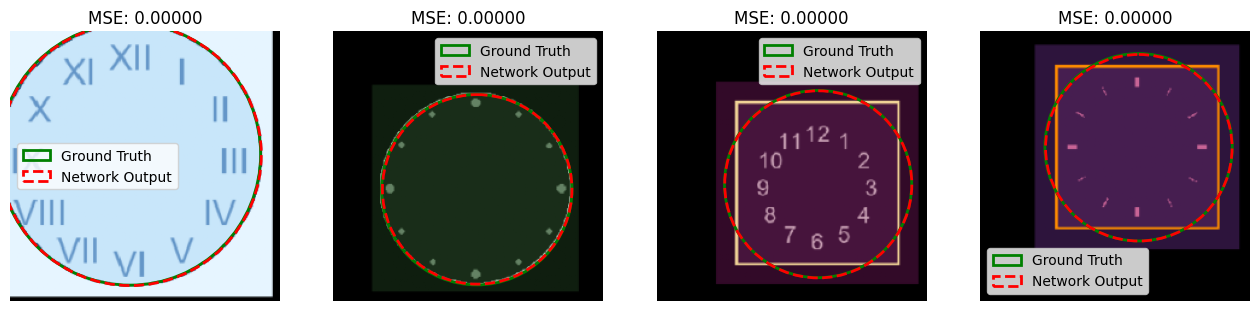

In [6]:
# ==========================================
# CELL 5: Validation & Diagnostics
# ==========================================
def evaluate_geometry_predictions(src_directory="../datasets"):
    eval_net = SpatialBoundsResNet().to(compute_device)
    try:
        eval_net.load_state_dict(torch.load("checkpoints/geometry_net_best.pth", map_location=compute_device))
        print("Model weights successfully loaded.")
    except FileNotFoundError:
        print("Checkpoint missing. Please run the training loop first.")
        return

    eval_net.eval()
    
    eval_data = ClockFaceBoundsDataset(base_path=src_directory, partition='test')
    eval_loader = DataLoader(eval_data, batch_size=4, shuffle=True)
    
    batch_imgs, batch_targets = next(iter(eval_loader))
    batch_imgs_gpu = batch_imgs.to(compute_device)
    
    with torch.no_grad():
        network_preds = eval_net(batch_imgs_gpu).cpu() 
        
    figure, axs = plt.subplots(1, 4, figsize=(16, 4))
    loss_calc = nn.MSELoss()
    
    for col in range(4):
        ax = axs[col]
        img_array = batch_imgs[col].permute(1, 2, 0).numpy()
        ax.imshow(img_array)
        
        img_h, img_w, _ = img_array.shape
        
        # Map out Ground Truth 
        true_x, true_y, true_r = batch_targets[col]
        circle_true = plt.Circle((true_x * img_w, true_y * img_h), true_r * img_w, 
                                 color='green', fill=False, linewidth=2, label='Ground Truth')
        ax.add_patch(circle_true)
        
        # Map out Predicted Bounds
        pred_x, pred_y, pred_r = network_preds[col]
        circle_pred = plt.Circle((pred_x * img_w, pred_y * img_h), pred_r * img_w, 
                                 color='red', fill=False, linewidth=2, linestyle='--', label='Network Output')
        ax.add_patch(circle_pred)
        
        ax.legend()
        ax.set_title(f"MSE: {loss_calc(network_preds[col], batch_targets[col]):.5f}")
        ax.axis('off')
    
    plt.show()

# Run Evaluation
if __name__ == "__main__":
    evaluate_geometry_predictions(src_directory="../datasets")